In [1]:
from imports import *  # noqa: F403

I0000 00:00:1783372558.938828   22665 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
required = ["training.csv", "test.csv"]
data_dir = "./data"

os.makedirs(data_dir, exist_ok=True)

missing = [f for f in required if not os.path.isfile(os.path.join(data_dir, f))]

if missing:
    print(f"Missing files: {missing}. Downloading...")
    !kaggle competitions download -c DontGetKicked -p {data_dir}

    while any(f.endswith(".zip") for f in os.listdir(data_dir)):
        for item in os.listdir(data_dir):
            if item.endswith(".zip"):
                zip_path = os.path.join(data_dir, item)
                with zipfile.ZipFile(zip_path, "r") as z:
                    z.extractall(data_dir)
                os.remove(zip_path)
                print(f"Extracted and removed: {item}")

    print("Done.")
else:
    print("All files already exist.")

All files already exist.


In [3]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

pd.set_option("display.max_colwidth", 500)
pd.set_option("display.width", 1000)

### EDA

In [4]:
# ----------------------------------------------------------------------
# 1. Загрузка и первичный анализ
# ----------------------------------------------------------------------
df = pd.read_csv("./data/training.csv")
print("Размерность:", df.shape)
display(df.T)

print("\n--- Типы данных ---")
print(df.dtypes.value_counts())

print("\n--- Пропуски ---")
missing = df.isnull().sum()
display(missing[missing > 0])

Размерность: (72983, 34)


,0,1,2,3,4,5,6,7,8,9,...,72973,72974,72975,72976,72977,72978,72979,72980,72981,72982
RefId,1,2,3,4,5,6,7,8,9,10,...,73005,73006,73007,73008,73009,73010,73011,73012,73013,73014
IsBadBuy,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
PurchDate,12/7/2009,12/7/2009,12/7/2009,12/7/2009,12/7/2009,12/7/2009,12/7/2009,12/7/2009,12/7/2009,12/7/2009,...,11/24/2009,12/2/2009,12/2/2009,12/2/2009,12/2/2009,12/2/2009,12/2/2009,12/2/2009,12/2/2009,12/2/2009
Auction,ADESA,ADESA,ADESA,ADESA,ADESA,ADESA,ADESA,ADESA,ADESA,ADESA,...,ADESA,ADESA,ADESA,ADESA,ADESA,ADESA,ADESA,ADESA,ADESA,ADESA
VehYear,2006,2004,2005,2004,2005,2004,2004,2005,2007,2007,...,2006,2002,2007,2004,2006,2001,2007,2005,2006,2006
VehicleAge,3,5,4,5,4,5,5,4,2,2,...,3,7,2,5,3,8,2,4,3,3
Make,MAZDA,DODGE,DODGE,DODGE,FORD,MITSUBISHI,KIA,FORD,KIA,FORD,...,CHRYSLER,DODGE,HYUNDAI,FORD,KIA,MERCURY,CHEVROLET,JEEP,CHEVROLET,MAZDA
Model,MAZDA3,1500 RAM PICKUP 2WD,STRATUS V6,NEON,FOCUS,GALANT 4C,SPECTRA,TAURUS,SPECTRA,FIVE HUNDRED,...,300,1500 RAM PICKUP 2WD,SONATA V6,EXPLORER 2WD V6,SORENTO 2WD,SABLE,MALIBU 4C,GRAND CHEROKEE 2WD V,IMPALA,MAZDA6
Trim,i,ST,SXT,SXT,ZX3,ES,EX,SE,EX,SEL,...,Bas,ST,Lim,XLS,EX,GS,LS,Lar,LS,s
SubModel,4D SEDAN I,QUAD CAB 4.7L SLT,4D SEDAN SXT FFV,4D SEDAN,2D COUPE ZX3,4D SEDAN ES,4D SEDAN EX,4D SEDAN SE,4D SEDAN EX,4D SEDAN SEL,...,4D SEDAN,QUAD CAB 4.7L SLT,4D SEDAN,4D SUV 4.0L FFV XLS,4D SPORT UTILITY EX,4D SEDAN GS,4D SEDAN LS,4D WAGON LAREDO,4D SEDAN LS,4D SEDAN S



--- Типы данных ---
object     15
float64    10
int64       9
Name: count, dtype: int64

--- Пропуски ---


Trim                                  2360
SubModel                                 8
Color                                    8
Transmission                             9
WheelTypeID                           3169
WheelType                             3174
Nationality                              5
Size                                     5
TopThreeAmericanName                     5
MMRAcquisitionAuctionAveragePrice       18
MMRAcquisitionAuctionCleanPrice         18
MMRAcquisitionRetailAveragePrice        18
MMRAcquisitonRetailCleanPrice           18
MMRCurrentAuctionAveragePrice          315
MMRCurrentAuctionCleanPrice            315
MMRCurrentRetailAveragePrice           315
MMRCurrentRetailCleanPrice             315
PRIMEUNIT                            69564
AUCGUART                             69564
dtype: int64

In [5]:
# ----------------------------------------------------------------------
# 2. Анализ константных и почти константных признаков
# ----------------------------------------------------------------------
constant_cols = [col for col in df.columns if df[col].nunique() <= 1]
print(f"Константные колонки: {constant_cols}")

for col in df.select_dtypes(include="object").columns:
    top_freq = df[col].value_counts(normalize=True).iloc[0]
    if top_freq > 0.95:
        print(f"Почти константная: {col} (частота {top_freq:.2%})")

Константные колонки: []
Почти константная: Transmission (частота 96.47%)
Почти константная: PRIMEUNIT (частота 98.19%)
Почти константная: AUCGUART (частота 97.69%)



--- Статистика числовых признаков ---


,count,mean,std,min,1%,5%,50%,95%,99%,max
RefId,72983.0,36511.428497,21077.241302,1.0,730.82,3652.10,36514.0,69364.90,72284.18,73014.0
IsBadBuy,72983.0,0.122988,0.328425,0.0,0.00,0.00,0.0,1.00,1.00,1.0
VehYear,72983.0,2005.343052,1.731252,2001.0,2001.00,2002.00,2005.0,2008.00,2009.00,2010.0
VehicleAge,72983.0,4.176644,1.712210,0.0,1.00,2.00,4.0,7.00,8.00,9.0
WheelTypeID,69814.0,1.494299,0.521290,0.0,1.00,1.00,1.0,2.00,3.00,3.0
VehOdo,72983.0,71499.995917,14578.913128,4825.0,35653.56,45477.00,73361.0,92521.80,98262.90,115717.0
MMRAcquisitionAuctionAveragePrice,72965.0,6128.909217,2461.992768,0.0,0.00,2583.00,6097.0,10244.00,12457.08,35722.0
MMRAcquisitionAuctionCleanPrice,72965.0,7373.636031,2722.491986,0.0,1.00,3500.00,7303.0,12030.80,14623.36,36859.0
MMRAcquisitionRetailAveragePrice,72965.0,8497.034332,3156.285284,0.0,0.00,3617.20,8444.0,13742.00,16019.72,39080.0
MMRAcquisitonRetailCleanPrice,72965.0,9850.928240,3385.789541,0.0,0.00,4646.20,9789.0,15454.80,18054.08,41482.0


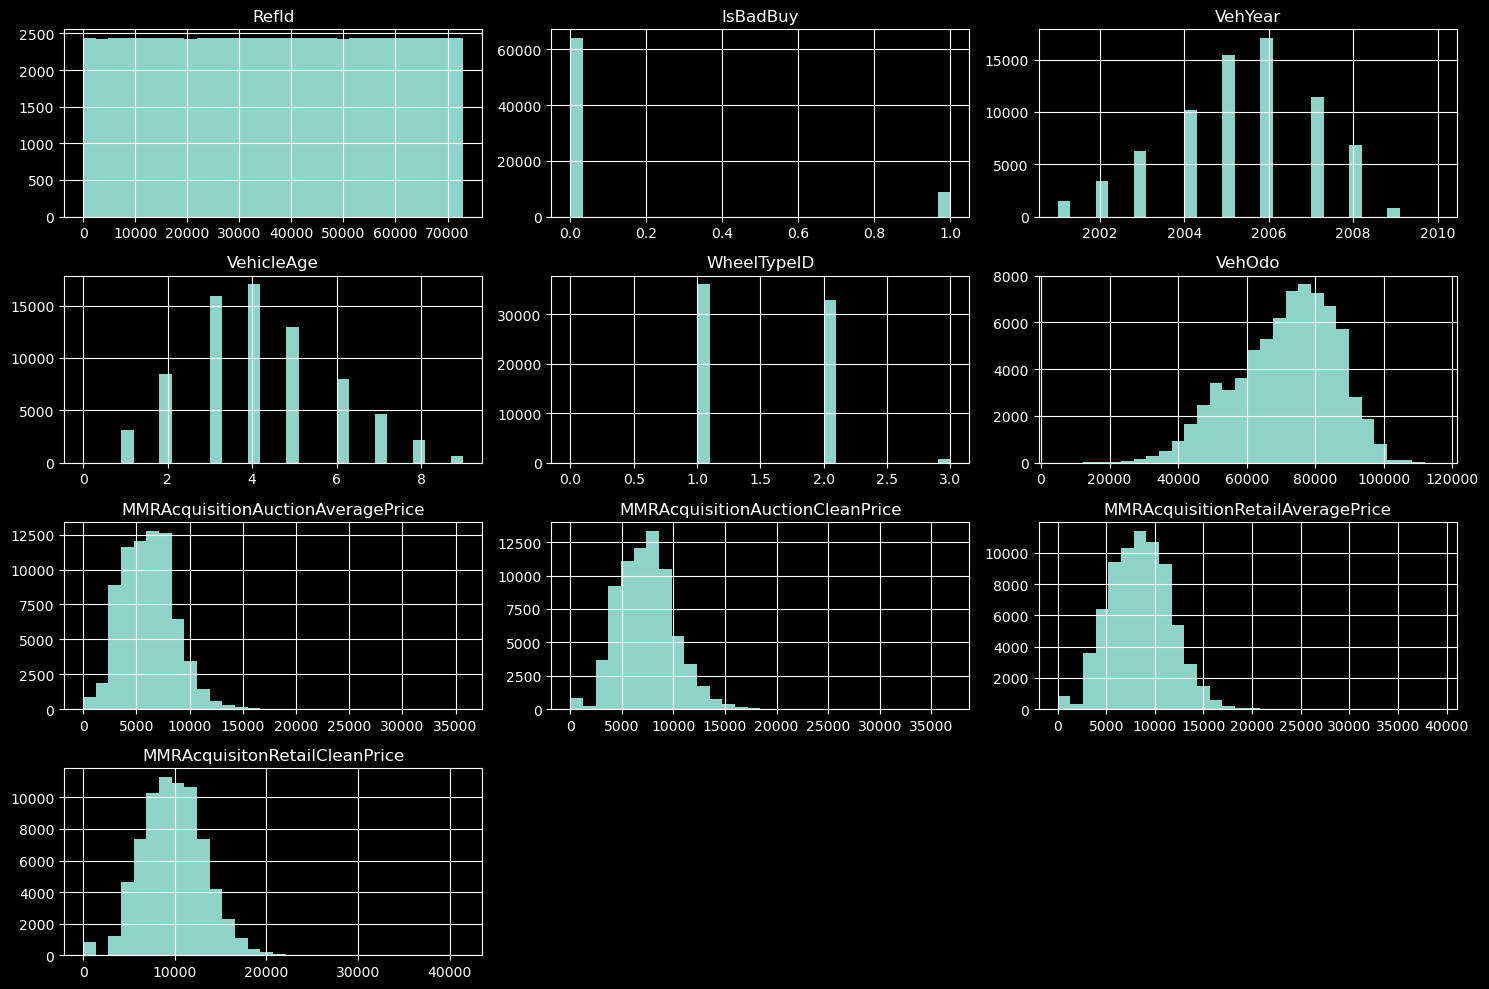

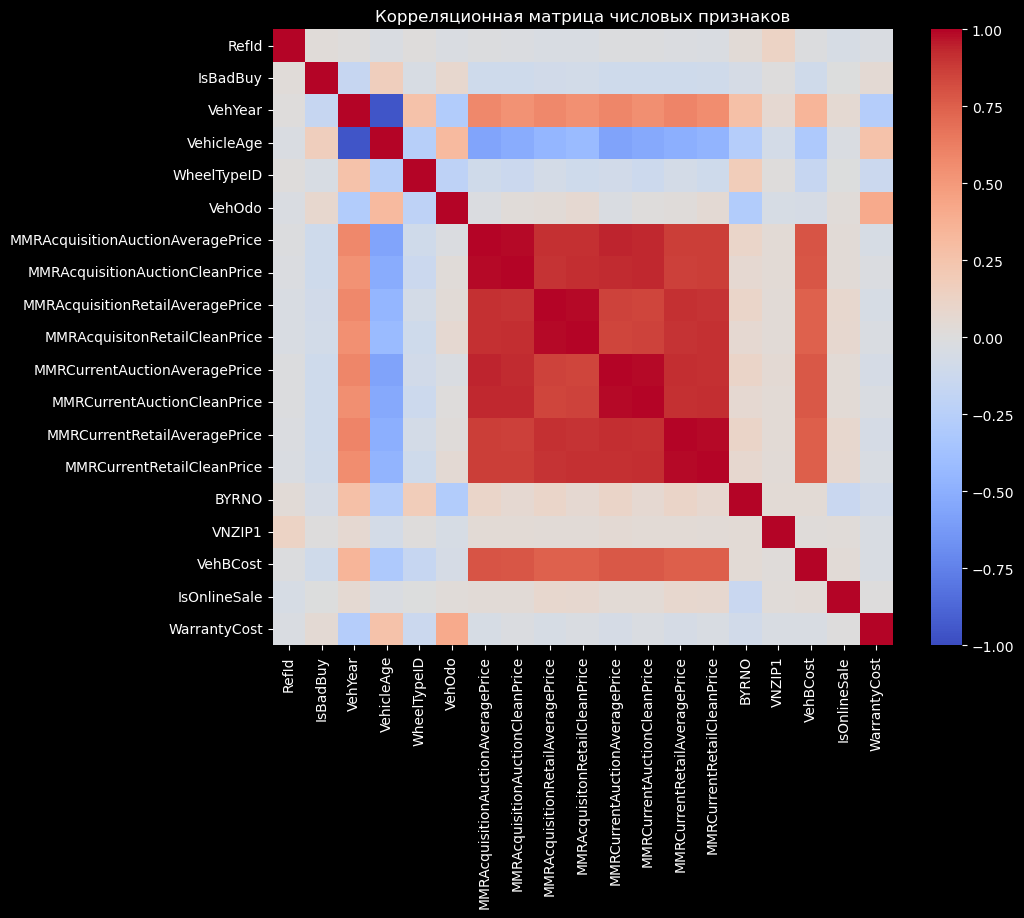

Признаки с высокой корреляцией (>0.95):
  VehYear – VehicleAge: -0.958
  MMRAcquisitionAuctionAveragePrice – MMRAcquisitionAuctionCleanPrice: 0.990
  MMRAcquisitionRetailAveragePrice – MMRAcquisitonRetailCleanPrice: 0.990
  MMRCurrentAuctionAveragePrice – MMRCurrentAuctionCleanPrice: 0.990
  MMRCurrentRetailAveragePrice – MMRCurrentRetailCleanPrice: 0.990


In [6]:
# ----------------------------------------------------------------------
# 3. Анализ числовых признаков (распределения, выбросы, корреляция)
# ----------------------------------------------------------------------
num_cols = df.select_dtypes(include=np.number).columns.tolist()
print("\n--- Статистика числовых признаков ---")
display(df[num_cols].describe(percentiles=[0.01, 0.05, 0.95, 0.99]).T)

df[num_cols[:10]].hist(bins=30, figsize=(15, 10))
plt.tight_layout()
plt.show()

corr = df[num_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=False, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Корреляционная матрица числовых признаков")
plt.show()

high_corr = np.where(np.abs(corr) > 0.95)
high_corr_pairs = [
    (corr.index[i], corr.columns[j], corr.iloc[i, j])
    for i, j in zip(high_corr[0], high_corr[1])
    if i < j
]
print("Признаки с высокой корреляцией (>0.95):")
for pair in high_corr_pairs:
    print(f"  {pair[0]} – {pair[1]}: {pair[2]:.3f}")

In [7]:
# ----------------------------------
# 4. Анализ категориальных признаков
# ----------------------------------
cat_cols = df.select_dtypes(include="object").columns.tolist()
rows = []
for col in cat_cols:
    n = df[col].nunique()
    top_values = df[col].value_counts().iloc[:3]
    top_str = ", ".join([f"{k} ({v})" for k, v in top_values.items()])
    rows.append({"Признак": col, "Уникальных": n, "Топ-3 значения (частота)": top_str})

cat_stats = pd.DataFrame(rows)
display(cat_stats)

,Признак,Уникальных,Топ-3 значения (частота)
0,PurchDate,517,"11/23/2010 (384), 2/25/2009 (379), 12/8/2010 (372)"
1,Auction,3,"MANHEIM (41043), OTHER (17501), ADESA (14439)"
2,Make,33,"CHEVROLET (17248), DODGE (12912), FORD (11305)"
3,Model,1063,"PT CRUISER (2329), IMPALA (1990), TAURUS (1425)"
4,Trim,134,"Bas (13950), LS (10174), SE (9348)"
5,SubModel,863,"4D SEDAN (15236), 4D SEDAN LS (4718), 4D SEDAN SE (3859)"
6,Color,16,"SILVER (14875), WHITE (12123), BLUE (10347)"
7,Transmission,3,"AUTO (70398), MANUAL (2575), Manual (1)"
8,WheelType,3,"Alloy (36050), Covers (33004), Special (755)"
9,Nationality,4,"AMERICAN (61028), OTHER ASIAN (8033), TOP LINE ASIAN (3722)"


In [8]:
# -----------------------------------
# 5. Временной анализ (сплит по дате)
# -----------------------------------
df = add_datetime_features(df, "PurchDate")  # добавляем год, месяц, день, is_weekend
df["Model"] = df.apply(clean_model_from_sub_and_trim, axis=1)
df["Model"] = df["Model"].replace("", "missing").fillna("missing")

train_df, val_df, test_df = train_val_test_data_split(df)
base_date = train_df["PurchDate"].min()
train_df, val_df, test_df = [
    preprocess_split(df, base_date) for df in [train_df, val_df, test_df]
]

print("\n--- Тест Колмогорова-Смирнова для числовых признаков (train vs val) ---")
num_cols = train_df.select_dtypes(include=np.number).columns.tolist()
unstable_num = []
for col in num_cols:
    if col in ["IsBadBuy"]:
        continue
    stat, p = ks_2samp(train_df[col].dropna(), val_df[col].dropna())
    if p < 0.05:
        unstable_num.append(col)
        print(f"{col}: p={p:.4f} (нестабилен)")

# Сравнение категориальных (χ²-тест)
cat_cols = train_df.select_dtypes(include="object").columns.tolist()
unstable_cat = []
for col in cat_cols:
    if col in ["IsBadBuy"]:
        continue
    # Строим таблицу сопряжённости
    cont_table = pd.crosstab(train_df[col], val_df[col])
    if cont_table.shape[0] > 1 and cont_table.shape[1] > 1:
        chi2, p, dof, expected = chi2_contingency(cont_table)
        if p < 0.05:
            unstable_cat.append(col)
            print(f"{col}: p={p:.4f} (нестабилен)")


--- Тест Колмогорова-Смирнова для числовых признаков (train vs val) ---
RefId: p=0.0000 (нестабилен)
VehYear: p=0.0000 (нестабилен)
VehicleAge: p=0.0000 (нестабилен)
VehOdo: p=0.0000 (нестабилен)
MMRAcquisitionAuctionAveragePrice: p=0.0000 (нестабилен)
MMRAcquisitionAuctionCleanPrice: p=0.0000 (нестабилен)
MMRAcquisitionRetailAveragePrice: p=0.0000 (нестабилен)
MMRAcquisitonRetailCleanPrice: p=0.0000 (нестабилен)
MMRCurrentAuctionAveragePrice: p=0.0000 (нестабилен)
MMRCurrentAuctionCleanPrice: p=0.0000 (нестабилен)
MMRCurrentRetailAveragePrice: p=0.0000 (нестабилен)
MMRCurrentRetailCleanPrice: p=0.0000 (нестабилен)
BYRNO: p=0.0000 (нестабилен)
VNZIP1: p=0.0000 (нестабилен)
VehBCost: p=0.0000 (нестабилен)
IsOnlineSale: p=0.0000 (нестабилен)
WarrantyCost: p=0.0000 (нестабилен)
year: p=0.0000 (нестабилен)
month: p=0.0000 (нестабилен)
dayofweek: p=0.0000 (нестабилен)
days_since_start: p=0.0000 (нестабилен)
month_sin: p=0.0000 (нестабилен)
month_cos: p=0.0000 (нестабилен)


In [9]:
drop_cols = [
    "IsBadBuy",
    "PurchDate",
    "year",
    "IsOnlineSale",
    "is_weekend",
    "PRIMEUNIT",
    "AUCGUART",
    "WheelTypeID",
    "days_since_start",
]

X_train, X_val, X_test, y_train, y_val, y_test, pipeline = prepare_data(
    "./data/training.csv", drop_cols=drop_cols
)

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

feature_names = pipeline.named_steps["preprocessor"].get_feature_names_out()

importances = rf.feature_importances_
sorted_idx = np.argsort(importances)[::-1]

/home/semiotia/anaconda3/envs/ml/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2, 4, 5, 6, 7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/home/semiotia/anaconda3/envs/ml/lib/python3.10/site-packages/category_encoders/count.py:169: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X[col] = X[col].map(self._min_group_categories[col]).fillna(X[col])
/home/semiotia/anaconda3/envs/ml/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/home/semiotia/anaconda3/envs/ml/lib/python3.10/site-packages/category_e

In [ ]:
print("\n--- Топ важных признаков (RandomForest) ---")
for i in range(91):
    print(
        f"{i + 1:2d}. {feature_names[sorted_idx[i]]}: {importances[sorted_idx[i]]:.4f}"
    )


--- Топ-25 важных признаков (RandomForest) ---
 1. ohe__WheelType_Unknown: 0.1066
 2. num__VehOdo: 0.0550
 3. num__VehBCost: 0.0512
 4. num__MMRCurrentRetailCleanPrice: 0.0410
 5. num__MMRCurrentAuctionCleanPrice: 0.0408
 6. num__MMRCurrentAuctionAveragePrice: 0.0403
 7. num__MMRCurrentRetailAveragePrice: 0.0385
 8. num__MMRAcquisitionRetailAveragePrice: 0.0382
 9. count__VNZIP1: 0.0380
10. num__MMRAcquisitionAuctionAveragePrice: 0.0371
11. num__MMRAcquisitionAuctionCleanPrice: 0.0371
12. num__WarrantyCost: 0.0365
13. num__MMRAcquisitonRetailCleanPrice: 0.0359
14. count__BYRNO: 0.0340
15. count__Model: 0.0263
16. count__SubModel: 0.0252
17. count__Trim: 0.0209
18. num__month: 0.0206
19. num__month_cos: 0.0203
20. num__month_sin: 0.0202
21. num__dayofweek: 0.0175
22. count__Make: 0.0171
23. num__VehicleAge: 0.0143
24. num__VehYear: 0.0143
25. ohe__Auction_MANHEIM: 0.0098
26. ohe__WheelType_Covers: 0.0085
27. ohe__VNST_TX: 0.0074
28. ohe__Color_SILVER: 0.0071
29. ohe__Color_WHITE: 0.006

| Признак | Причина удаления |
|---------|-------------------|
| `IsBadBuy` | Целевая переменная (вынесена в `y`). |
| `PurchDate` | Исходная дата – заменена на производные признаки (месяц, день недели, циклические). |
| `year` | Дублирует `days_since_start`, усиливает временной тренд. |
| `IsOnlineSale` | Почти константа (>97% нулей), неинформативен. |
| `is_weekend` | Константа (все значения 0). |
| `PRIMEUNIT` | Почти константа (>98% значений `"NO"`). |
| `AUCGUART` | Почти константа (>97% значений `"GREEN"`). |
| `WheelTypeID` | Дублирует категориальный `WheelType`. |
| `days_since_start` | Монотонный временной тренд, усиливает сдвиг распределения между выборками. |
| `Color` | Суммарная важность < 0.05; все бинарные колонки имеют важность < 0.01 (RandomForest). |
| `Auction` | Важность отдельных категорий < 0.01 (суммарно < 0.02). |
| `VNST` | Важность размазана по множеству штатов, каждая < 0.01, суммарно ~0.05. |
| `Size` | Важность отдельных значений < 0.005, суммарно ~0.02. |
| `TopThreeAmericanName` | Суммарная важность ~0.012. |
| `Nationality` | Важность отдельных категорий < 0.003. |
| `Transmission` | Важность < 0.003 (кроме `MANUAL` 0.0022). |

### Task 1

Download the data from the [Don'tGetKicked contest](https://www.kaggle.com/c/DontGetKicked).

Design a train/validation/test split.

Use the "PurchDate" field for the split, test must be later in time than validation, same goes for validation and train: train.PurchDate < valid.PurchDate < test.PurchDate.
Use the first 33% of the dates for the train, the last 33% of the dates for the test, and the middle 33% for the validation set. *Don't use the test dataset until the end!*

Use sklearn's LabelEncoder or OneHotEncoder to preprocess categorical variables. Be careful with data leakage (fit Encoder to train and apply to validation & test). Consider another coding approach if you encounter new categorical values in validation & test (not seen in training).

In [ ]:
drop_cols = [
    "IsBadBuy",
    "PurchDate",
    "year",
    "IsOnlineSale",
    "is_weekend",
    "PRIMEUNIT",
    "AUCGUART",
    "WheelTypeID",
    "days_since_start",
    "Color",
    "Auction",
    "VNST",
    "Size",
    "TopThreeAmericanName",
    "Nationality",
    "Transmission",
]

X_train, X_val, X_test, y_train, y_val, y_test = prepare_data(drop_cols=drop_cols)

### Task 2 - 3

Create a Python class, MLP with 1 hidden layer and sigmoid activation function at the end of the network.
It should support *fit, predict_proba* and *predict methods*. Also, the number of neurons in the hidden layer and the activation function must be parameters of your class.

- Initialize the network with small random numbers.
- Use Log Loss (Binary Cross Entropy) as the loss function.
- Implement a forward pass; you can use a fixed batch size like 32, forward pass maps arrays of shape (batch_size, number_of_features) to arrays of shape (batch_size, 2) where 2 means dimensions of [probability_of_0, probability_of_1] output space.
- Write down the gradients of the loss function with respect to the parameters of the net.
- Use gradients to perform Backprop. Implement Backprop.
- Implement SGD algorithm to tune model parameters.
- Design a basic train-validation loop: iterate over the training dataset, batch by batch, update the parameters of the network, and check the quality of the model using the validation set.
- Write code to update network weights using SGD or Adam.

With your MLP module and careful network engineering, you must obtain at least a 0.15 Gini score on the validation dataset. You can train for more than 1 epoch, use different activation functions, and different optimizers (like SGD or Adam).

In [ ]:
# def objective(trial):
#     l2_lambda = trial.suggest_float("l2_lambda", 0.001, 0.75, log=False)
#     model = MLP(
#         l2_lambda=l2_lambda,
#     )

#     model.fit(
#         X_train,
#         y_train,
#         X_val,
#         y_val,
#         epochs=100,
#         batch_size=128,
#         verbose=False,
#     )

#     proba_train = model.predict_proba(X_train)[:, 1]
#     proba_val = model.predict_proba(X_val)[:, 1]

#     train_gini = 2 * roc_auc_score(y_train, proba_train) - 1
#     val_gini = 2 * roc_auc_score(y_val, proba_val) - 1

#     penalty = abs(train_gini - val_gini)
#     score = val_gini - 0.5 * penalty

#     trial.set_user_attr("train_gini", train_gini)
#     trial.set_user_attr("val_gini", val_gini)
#     trial.set_user_attr("penalty", penalty)
#     trial.set_user_attr("l2_lambda", l2_lambda)

#     return score


# study = optuna.create_study(direction="maximize", pruner=MedianPruner())
# study.optimize(objective, n_trials=30, show_progress_bar=True)

# print("Best trial:")
# print("  Params:", study.best_params)
# print("  Score:", study.best_value)
# print("  Train Gini:", study.best_trial.user_attrs["train_gini"])
# print("  Val Gini:", study.best_trial.user_attrs["val_gini"])
# print("  Penalty:", study.best_trial.user_attrs["penalty"])
# print("  L2 lambda:", study.best_trial.user_attrs["l2_lambda"])

In [ ]:
results = {}

In [ ]:
params_custom_MLP = {
    "activation_func": "sigmoid",
    "optimizer": "adam",
    "l2_lambda": 0.03438351351362118,
}

model_custom_MLP = MLP(**params_custom_MLP)
model_custom_MLP.fit(
    X_train,
    y_train,
    X_val,
    y_val,
    early_stopping_min_delta=0.001,
    early_stopping_patience=10,
    batch_size=128,
    verbose=True,
)
proba = model_custom_MLP.predict_proba(X_train)[:, 1]
train_gini = 2 * roc_auc_score(y_train, proba) - 1

proba = model_custom_MLP.predict_proba(X_val)[:, 1]
val_gini = 2 * roc_auc_score(y_val, proba) - 1
print(f"{train_gini} - {val_gini}")

results["model_custom_MLP"] = val_gini

### Task 4

Use sklearn's MLPClassifier and check its performance on the validation dataset. Is it better than your module? If so, why?

In [ ]:
params_sk_MLP = {
    "hidden_layer_sizes": 100,
    "activation": "logistic",
    "solver": "adam",
    "alpha": 0.03438351351362118,
    "early_stopping": True,
    "random_state": 42,
}

model_sk = skMLP(**params_sk_MLP)
model_sk.fit(X_train, y_train)


proba = model_sk.predict_proba(X_train)[:, 1]
gini_train = 2 * roc_auc_score(y_train, proba) - 1

proba = model_sk.predict_proba(X_val)[:, 1]
gini_val = 2 * roc_auc_score(y_val, proba) - 1
print(f"{gini_train} - {gini_val}")

results["model_sklearn_MLP"] = gini_val

### Task 5

Implement and try different activation functions: sigmoid, ReLU, cosine. Remember that you have to derive gradients for each different activation function. Which activation function gives the best performance on the validation dataset?

In [ ]:
for act_func in ["relu", "cos", "tanh", "elu"]:
    params = {
        "learning_rate": 0.01,
        "optimizer": "adam",
        "l2_lambda": 0.03438351351362118,
    }
    model = MLP(**params)
    model.fit(
        X_train,
        y_train,
        X_val,
        y_val,
        early_stopping_min_delta=0.001,
        early_stopping_patience=10,
        batch_size=128,
        verbose=True,
    )

    proba = model.predict_proba(X_val)[:, 1]
    gini = 2 * roc_auc_score(y_val, proba) - 1
    print(f"Функция активации: {act_func}, Gini : {gini}")
    results[f"model_{act_func}"] = gini

### Task 6

Design an MLP module with 1 hidden layer using any high level deep learning framework: Pytorch, Keras, or Tensorflow. Check its performance on the validation dataset.  Is it better than your module? If so, why?

In [ ]:
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

best_init = keras.initializers.GlorotUniform(seed=SEED)
best_lr = 0.0001
best_neurons = 50

inputs = keras.Input(shape=(X_train.shape[1],))
x = keras.layers.Dense(
    best_neurons,
    activation="sigmoid",
    kernel_initializer=best_init,
    bias_initializer=keras.initializers.Zeros(),
)(inputs)
outputs = keras.layers.Dense(
    1,
    activation="sigmoid",
    kernel_initializer=keras.initializers.GlorotUniform(seed=SEED + 1),
    bias_initializer=keras.initializers.Zeros(),
)(x)
model_tf = keras.Model(inputs=inputs, outputs=outputs)

model_tf.compile(
    optimizer=keras.optimizers.Adam(learning_rate=best_lr),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1,
)

history = model_tf.fit(
    X_train,
    y_train,
    batch_size=128,
    epochs=100,
    validation_data=(X_val, y_val),
    shuffle=True,
    callbacks=[early_stop],
    verbose=0,
)

proba_tf = model_tf.predict(X_val).ravel()
gini_tf = 2 * roc_auc_score(y_val, proba_tf) - 1
print(f"Keras (best params) Gini: {gini_tf:.4f}")

results["model_tensorflow_best"] = gini_tf

In [ ]:
df_results = pd.DataFrame(results, index=["Метрика Gini на валидации"])
display(df_results.T)

In [ ]:
proba = model_sk.predict_proba(X_test)[:, 1]
gini = 2 * roc_auc_score(y_test, proba) - 1
print(f"Gini лучшей модели на тестовой выборке: {gini}")